In [30]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets
import matplotlib.pyplot as plt
import os
import csv
import transformer
import importlib
from sklearn.model_selection import train_test_split

In [31]:
PATH_D = "Series temporales/DNI/"
NUM_S = 3
SENSORS = ["S1", "S3", "S4"]

In [32]:
def get_series():
    """Devuelve la lista total de días válidos e inválidos para cada
       sensor.

    Returns:
        list: una matriz, donde:
            dim. 0: número de sensor
            dim. 1: válidos/inválidos
    """
    series = []
    for i in range(NUM_S):
        validos = sorted(os.listdir(PATH_D + SENSORS[i] + "/series/validas"))
        invalidos = sorted(os.listdir(PATH_D + SENSORS[i] + "/series/no validas"))
        series.append([validos,invalidos])
    return series

In [33]:
# series inválidas para sensor S1 (posición 0)
print(get_series()[0][1])

['2013-225', '2013-42', '2014-269', '2014-270', '2014-271', '2014-272', '2014-273', '2014-274', '2014-275', '2014-276', '2014-277', '2014-278', '2014-279', '2014-280', '2014-281', '2014-282', '2014-283', '2014-284', '2014-285', '2014-286', '2014-287', '2014-288', '2014-289', '2014-290', '2014-291', '2014-292', '2014-293', '2014-294', '2014-295', '2014-296', '2014-297', '2014-298', '2014-299', '2014-300', '2014-301', '2014-302', '2014-303', '2014-304', '2014-305', '2014-306', '2014-307', '2014-308', '2014-309', '2014-310', '2014-311', '2014-312', '2014-313', '2014-314', '2014-315', '2014-316', '2014-317', '2014-318', '2014-319', '2014-320', '2014-321', '2014-322', '2014-323', '2014-324', '2014-325', '2014-326', '2014-327', '2014-328', '2014-329', '2014-330', '2014-357', '2014-65', '2014-8', '2015-118', '2015-119', '2015-120', '2015-20', '2015-293', '2015-302', '2015-303', '2016-110', '2016-111', '2016-202', '2016-203', '2016-204', '2016-205', '2016-206', '2016-207', '2016-208', '2016-3'

In [34]:
def search_day(year,day,series):
    """Indica qué sensores presentan una serie válida para el día indicado.

    Args:
        year (int): el año del día
        day (int): el número de día
        series (list): matriz del tipo
            que devuelve get_series()

    Returns:
        param (list): lista de 3 elementos. Cada elemento indica si la serie es
            válida para el sensor de esa posición. 0: válido, 1: inválido
            ejemplo: [1,0,0] Inválido para S1, válido para S3 y S4.

    """
    name = str(year) + '-' + str(day)
    param = []
    for i in range(NUM_S):
        for j in range(2):
            if name in series[i][j]:
                param.append(float(j))
    return param

In [35]:
series = get_series()

In [36]:
# Ejemplo de search_day
print(search_day(2015,68,series))

[0.0, 0.0, 0.0]


In [37]:
# Aquí se revisa si falta algún día que no aparezca en el set de datos.
# los días que falten se muestran por pantalla.
# (Se muestran días de 2019 porque de este año solo se tiene medio año
# en el set de datos)
for y in range(2013,2020):
    for d in range(1,366):
        if (len(search_day(y,d,series)) != 3):
            print(str(y)+"-"+str(d))

2019-182
2019-183
2019-184
2019-185
2019-186
2019-187
2019-188
2019-189
2019-190
2019-191
2019-192
2019-193
2019-194
2019-195
2019-196
2019-197
2019-198
2019-199
2019-200
2019-201
2019-202
2019-203
2019-204
2019-205
2019-206
2019-207
2019-208
2019-209
2019-210
2019-211
2019-212
2019-213
2019-214
2019-215
2019-216
2019-217
2019-218
2019-219
2019-220
2019-221
2019-222
2019-223
2019-224
2019-225
2019-226
2019-227
2019-228
2019-229
2019-230
2019-231
2019-232
2019-233
2019-234
2019-235
2019-236
2019-237
2019-238
2019-239
2019-240
2019-241
2019-242
2019-243
2019-244
2019-245
2019-246
2019-247
2019-248
2019-249
2019-250
2019-251
2019-252
2019-253
2019-254
2019-255
2019-256
2019-257
2019-258
2019-259
2019-260
2019-261
2019-262
2019-263
2019-264
2019-265
2019-266
2019-267
2019-268
2019-269
2019-270
2019-271
2019-272
2019-273
2019-274
2019-275
2019-276
2019-277
2019-278
2019-279
2019-280
2019-281
2019-282
2019-283
2019-284
2019-285
2019-286
2019-287
2019-288
2019-289
2019-290
2019-291
2019-292
2

In [38]:
def reshape_series(series):
    """ Devuelve el dataset en un formato diferente.

    Args:
        series (list): dataset en formato devuelto por get_series()

    Returns:
        series_reshaped (list): Lista total de días donde cada elemento es 
            un día seguido por la lista devuelta por search_day() para ese
            día.
    """
    series_reshaped = []
    for y in range(2013,2020):
        for d in range(1,366):
            labels = search_day(y,d,series)
            if len(labels) == NUM_S:
                series_reshaped.append([str(y)+'-'+str(d),labels])

    return series_reshaped

In [39]:
# visualización del dataset devuelto por reshape_series
series = reshape_series(series)
print(series)

[['2013-1', [0.0, 0.0, 0.0]], ['2013-2', [0.0, 0.0, 0.0]], ['2013-3', [0.0, 0.0, 0.0]], ['2013-4', [0.0, 0.0, 0.0]], ['2013-5', [0.0, 0.0, 0.0]], ['2013-6', [0.0, 0.0, 0.0]], ['2013-7', [0.0, 0.0, 0.0]], ['2013-8', [0.0, 0.0, 0.0]], ['2013-9', [0.0, 0.0, 0.0]], ['2013-10', [0.0, 0.0, 0.0]], ['2013-11', [0.0, 0.0, 0.0]], ['2013-12', [0.0, 0.0, 0.0]], ['2013-13', [0.0, 0.0, 0.0]], ['2013-14', [0.0, 0.0, 0.0]], ['2013-15', [0.0, 0.0, 0.0]], ['2013-16', [0.0, 0.0, 0.0]], ['2013-17', [0.0, 0.0, 1.0]], ['2013-18', [0.0, 0.0, 0.0]], ['2013-19', [0.0, 0.0, 1.0]], ['2013-20', [0.0, 0.0, 1.0]], ['2013-21', [0.0, 0.0, 1.0]], ['2013-22', [0.0, 0.0, 0.0]], ['2013-23', [0.0, 0.0, 0.0]], ['2013-24', [0.0, 0.0, 0.0]], ['2013-25', [0.0, 0.0, 0.0]], ['2013-26', [0.0, 0.0, 0.0]], ['2013-27', [0.0, 0.0, 0.0]], ['2013-28', [0.0, 0.0, 0.0]], ['2013-29', [0.0, 0.0, 0.0]], ['2013-30', [0.0, 0.0, 0.0]], ['2013-31', [0.0, 1.0, 0.0]], ['2013-32', [0.0, 1.0, 0.0]], ['2013-33', [0.0, 0.0, 0.0]], ['2013-34', [0.0, 

In [40]:
# Dataset utilizado para el modelo CNN_mem.
# Para cada día se tiene, además, la indicación vállidos/inválidos
# para el día anterior.

memory_series = series.copy()
for i in range(len(memory_series)):
    if i == 0:
        memory_series[i].append([0.0,0.0,0.0])
    else:
        memory_series[i].append(series[i-1][1])

In [41]:
print(memory_series)

[['2013-1', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-2', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-3', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-4', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-5', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-6', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-7', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-8', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-9', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-10', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-11', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-12', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-13', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-14', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-15', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-16', [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]], ['2013-17', [0.0, 0.0, 1.0], [0.0, 0.0, 0.0]], ['2013-18', [0.0, 0.0, 0.0], [0.0, 0.0, 1.0]], ['2013-19', [0.0, 0.0, 1.0], [0.0, 0.0, 0.0]], ['2013-20', [0.0, 0.0, 1.0], [0.0, 0.0, 1.0]], ['2013-21', [0.0, 0.0, 1.0], [0.0, 0.0, 1.0]], ['2013-22', [0.0, 0.0

In [42]:
def get_points(path):
    """ Devuelve la lista de puntos para el archivo de una serie temporal.

    Args:
        path (str): Ruta del archivo de la serie temporal

    Returns:
        y (list): Lista de puntos de la serie temporal
        
    """
    with open(path, newline='',encoding="utf-8") as csvfile:
        reader = csv.reader(csvfile, delimiter=',')
        for row in reader:
            if not '' in row:
                y = [float(x) for x in row]
            else:
                y = []
                for x in row:
                    y.append(float('2000')) if x == '' else y.append(float(x))
    return y

In [43]:
class dni(Dataset):
    """Dataset de pytorch de las series temporales de radiación directa

    Attributes:
        root_dir (str): La ruta base donde se encuentran las series temporales
        files (list): lista de los nombres de los archivos de las series
            temporales. Debe estar en el mismo formato que el devuelto por
            reshape_series()
    """
    def __init__(self, root_dir, files):
        self.root_dir = root_dir
        self.files = files              

    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, index):
        series = []
        item = self.files[index]
        for i in range(NUM_S):
            path = self.root_dir + SENSORS[i] + "/series" 
            path += ("/validas" if item[1][i] == 0 else "/no validas")
            path += "/" + item[0]
            series.append(get_points(path))

        return (torch.tensor(series), torch.tensor(item[1]))


In [44]:
class dni_mem(Dataset):
    """Dataset de pytorch de las series temporales de radiación directa para
    el modelo CNN_mem

    Importante: este dataset es experimental. No se puede usar puesto que utiliza
    información de clasificación aportada por un humano.

    Attributes:
        root_dir (str): La ruta base donde se encuentran las series temporales
        files (list): lista de los nombres de los archivos de las series
            temporales. Debe estar en el mismo formato que el devuelto por
            reshape_series() y además tener cada día la información de validez del
            día anterior.
    """
    
    def __init__(self, root_dir, files):
        self.root_dir = root_dir
        self.files = files

    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, index):
        series = []
        item = self.files[index]
        for i in range(NUM_S):
            path = self.root_dir + SENSORS[i] + "/series" 
            path += ("/validas" if item[1][i] == 0 else "/no validas")
            path += "/" + item[0]
            series.append(get_points(path))
        return ([torch.tensor(series),torch.tensor(item[2])], torch.tensor(item[1]))

In [45]:
# División de las series temporales en train y test
# Se aplica la proporción por defecto: 75% train, 25% test
# train_series, test_series = train_test_split(series)
# train_series_mem, test_series_mem = train_test_split(memory_series)
train_series = series[:round(0.75*len(series))]
test_series = series[round(0.75*len(series)):]
train_series_mem, test_series_mem = train_test_split(memory_series)

In [46]:
print("Número de instancias en el conjunto de entrenamiento:",len(train_series))
print("Número de instancias en el conjunto de test:",len(test_series))

Número de instancias en el conjunto de entrenamiento: 1778
Número de instancias en el conjunto de test: 593


In [47]:
print(len(series))

2371


In [48]:
# tamaño del batch para entrenar el modelo. De momento no funciona bien
# si se emplea un tamaño diferente a 1.
batch_size = 1

In [49]:
def get_weights(train_series,coef=1):
    """Calcula los pesos necesarios para la función de pérdida
    de binary cross entropy

    Estos pesos son iguales al número de ejemplos negativos
    por cada positivo. Entendiendo como negativo: válido y
    positivo: inválido.

    Args:
        train_series: El dataset de entrenamiento, en formato
            igual al devuelto por reshape_series()
        coef: Coeficiente por el que se multiplican los pesos.
            Este parámetro es útil para modificar el balance
            precission-recall logrado por el modelo. Si coef>1,
            aumenta el recall. Si coef<1, aumenta la precission.

    Returns:
        lista de pesos, tiene tres elemenentos. Cada peso se
            calcula para cada sensor.
    """
    labels = np.zeros((len(train_series),NUM_S),dtype=float)
    for i in range(labels.shape[0]):
        labels[i] = train_series[i][1]

    labels = torch.tensor(labels)
    # Cuenta positivos y negativos por clase
    num_pos = labels.sum(dim=0)
    num_neg = labels.shape[0] - num_pos

    # Calcula el pos_weight
    pos_weight = num_neg / num_pos
    pos_weight = pos_weight
    return coef*pos_weight

In [50]:
labels = np.zeros((len(train_series),3),dtype=float)
for i in range(labels.shape[0]):
    labels[i] = train_series[i][1]

labels = torch.tensor(labels)
print(labels)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]], dtype=torch.float64)


In [51]:
# Cuenta positivos y negativos por clase
num_pos = labels.sum(dim=0)
num_neg = labels.shape[0] - num_pos

# Calcula el pos_weight
pos_weight = num_neg / num_pos
pos_weight = pos_weight
print(pos_weight)

tensor([11.5211,  5.6097,  8.4074], dtype=torch.float64)


In [52]:
# Los pesos pueden variar entre un dataset y otro porque cada
# vez que se ejecuta la función train_test_split, se generan
# los conjuntos de datos de manera aleatoria.

pos_weight = get_weights(train_series)
print("Pesos ds sin memoria:",pos_weight)
pos_weight_mem = get_weights(train_series_mem)
print("Pesos ds con memoria:",pos_weight_mem)

Pesos ds sin memoria: tensor([11.5211,  5.6097,  8.4074], dtype=torch.float64)
Pesos ds con memoria: tensor([5.1100, 5.7094, 8.4574], dtype=torch.float64)


In [53]:
dim_trans = 16

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = F.sigmoid(model(X))
        #y = torch.flatten(y)
        #pred = torch.flatten(pred)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # if (batch +1) % 100 == 0:
        #     loss, current = loss.item(), batch * batch_size + len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    positive_real, positive_pred, test_loss, correct, correct_pos = 0, 0, 0, 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = F.sigmoid(model(X))
            #y = torch.flatten(y)
            #pred = torch.flatten(pred)
            test_loss += loss_fn(pred, y).item()
            #print("PRED:",pred.round(),y)

            pred_pos = (pred.round() == 1.0)
            real_pos = (y == 1.0)
            positive_pred += pred_pos.type(torch.float).sum().item()
            positive_real += real_pos.type(torch.float).sum().item()
            correct_pos += torch.bitwise_and(pred_pos,real_pos).type(torch.float).sum().item()
            correct += (pred.round() == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= 3*size
    print(f"Test Error: \nAccuracy: \t {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}")
    print(f"Precission: \t {(100*correct_pos/positive_pred):>0.1f}%")
    print(f"Recall: \t {(100*correct_pos/positive_real):>0.1f}%")

    return test_loss, correct, correct_pos/positive_pred, correct_pos/positive_real


In [54]:
train_ds = dni(PATH_D,train_series)
test_ds = dni(PATH_D,test_series)

In [55]:
batch_size = 1
train_load = DataLoader(train_ds,batch_size=batch_size,shuffle=True,drop_last=True)
test_load = DataLoader(test_ds,batch_size=batch_size,shuffle=True,drop_last=True)

In [56]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [57]:
print(train_ds[0])

(tensor([[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,  11.1512,  11.1381,  11.3386,
          11.4654,  11.4180,  10.9283,  11.7676,  11.4375,  11.6464,  11.0729,
          11.4265,  10.9166,  11.4011,  11.6918,  11.6334,  11.3281,  11.3380,
          11.3000,  11.2163,  11.2704,  10.8753,  10.7840,  11.4500,  11.3033,
          10.7631,  11.5524,  11.9883,  22.7093, 652.6395,  56.1092, 287.1702,
         901.4286, 912.8788, 907.2903, 900.8758, 902.1469, 890.1874, 886.1212,
         879.5613, 878.7800, 874.9008, 851.0844, 84

In [58]:
importlib.reload(transformer)

vit = transformer.ViT(
    series_length=144,
    patch_length=6,
    num_sensors=NUM_S,
    dim=16,
    depth=4,
    heads=4,
    dim_head=8,
    mlp_dim=16
)

model = vit.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_mem)
optimizer = torch.optim.Adam(model.parameters(),lr=0.0005)

epochs = 20

loss = np.zeros(shape=(2,epochs),dtype=float)
accuracy = np.zeros(shape=(2,epochs),dtype=float)
precission = np.zeros(shape=(2,epochs),dtype=float)
recall = np.zeros(shape=(2,epochs),dtype=float)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_load, model, criterion, optimizer)
    print("Training dataset:")
    a,b,c,d = test_loop(train_load,model,criterion)
    loss[0,t], accuracy[0,t], precission[0,t], recall[0,t] = (a,b,c,d)
    print("")
    print("Test dataset:")
    loss[1,t], accuracy[1,t], precission[1,t], recall[1,t] = test_loop(test_load, model, criterion)
    print("")
print("Done!")


Epoch 1
-------------------------------
Training dataset:
Test Error: 
Accuracy: 	 94.8%, Avg loss: 0.941068
Precission: 	 77.6%
Recall: 	 76.2%

Test dataset:
Test Error: 
Accuracy: 	 92.9%, Avg loss: 1.129049
Precission: 	 94.8%
Recall: 	 73.9%

Epoch 2
-------------------------------
Training dataset:
Test Error: 
Accuracy: 	 95.3%, Avg loss: 0.917615
Precission: 	 78.9%
Recall: 	 79.8%

Test dataset:
Test Error: 
Accuracy: 	 91.8%, Avg loss: 1.113253
Precission: 	 92.2%
Recall: 	 71.0%

Epoch 3
-------------------------------
Training dataset:
Test Error: 
Accuracy: 	 93.4%, Avg loss: 0.921655
Precission: 	 67.4%
Recall: 	 79.5%

Test dataset:
Test Error: 
Accuracy: 	 89.7%, Avg loss: 1.118773
Precission: 	 83.2%
Recall: 	 70.0%

Epoch 4
-------------------------------
Training dataset:


KeyboardInterrupt: 

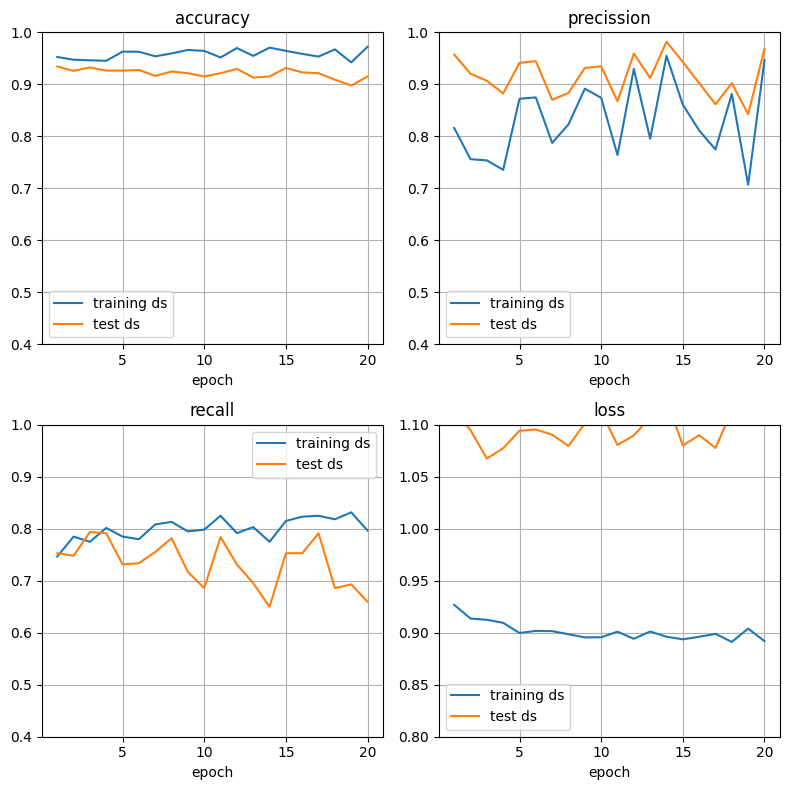

In [ ]:
x = range(1,1+epochs)
fig, ax = plt.subplots(2,2,figsize=(8,8))
ax[0,0].plot(x,accuracy[0,:], label="training ds")
ax[0,0].plot(x,accuracy[1,:], label="test ds")
ax[0,0].set_ylim(0.4,1)
ax[0,0].set_xlabel("epoch")
ax[0,0].grid()
ax[0,0].set_title("accuracy")
ax[0,0].legend()

ax[0,1].plot(x,precission[0,:], label="training ds")
ax[0,1].plot(x,precission[1,:], label="test ds")
ax[0,1].set_ylim(0.4,1)
ax[0,1].set_xlabel("epoch")
ax[0,1].grid()
ax[0,1].set_title("precission")
ax[0,1].legend()

ax[1,0].plot(x,recall[0,:], label="training ds")
ax[1,0].plot(x,recall[1,:], label="test ds")
ax[1,0].set_ylim(0.4,1)
ax[1,0].set_xlabel("epoch")
ax[1,0].grid()
ax[1,0].set_title("recall")
ax[1,0].legend()

ax[1,1].plot(x,loss[0,:], label="training ds")
ax[1,1].plot(x,loss[1,:], label="test ds")
ax[1,1].set_ylim(0.8,1.1)
ax[1,1].set_xlabel("epoch")
ax[1,1].grid()
ax[1,1].set_title("loss")
ax[1,1].legend()

fig.tight_layout()

plt.show()
